# Modelo No Supervisado — Segmentación de Contactos

**Objetivo**: Identificar segmentos naturales en la base de contactos usando clustering.

**Decisiones de diseño**:
- Reducción de dimensionalidad con **PCA** antes del clustering (reduce ruido, mejora separabilidad)
- Clustering con **K-Means** (escalable para 300k+ registros; se trabaja con muestra de 50k por viabilidad computacional)
- Número óptimo de clusters determinado por el **método del codo**
- Evaluación con **Silhouette Score** y perfilado por cluster
- Features: perfil vehicular (`MARCA`), operacional (`INTENTOS`, `Hora`, `MIN`) y de gestión (`ESTADO`, `CONTACTABILIDAD`, `EFECTIVIDAD`, `categoria`, `CALL`)

In [1]:
%pip install scikit-learn openpyxl --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

## 1. Preparación de Datos

In [3]:
# Carga del dataset
df = pd.read_excel('../DataSet/Antes/Consolidado_contacto_2026.xlsx')

# Filtrar registros con patente (contactos con vehículo vinculado)
df = df[df['PATENTE'].notna()].copy()
print(f"Registros con patente: {len(df):,}")

# Features para segmentación:
# - Operacionales: INTENTOS, Hora, MIN  (comportamiento de contacto)
# - Gestión: ESTADO, CONTACTABILIDAD, EFECTIVIDAD, categoria, CALL
# - Vehicular: MARCA
# Justificación: combinan perfil de gestión con características del cliente/vehículo
features_num = ['INTENTOS', 'Hora', 'MIN']
features_cat = ['MARCA', 'ESTADO', 'CONTACTABILIDAD', 'EFECTIVIDAD', 'categoria', 'CALL']

X = df[features_num + features_cat].copy()

# Imputar nulos en categóricas
X[features_cat] = X[features_cat].fillna('DESCONOCIDO')

# Label encoding
for col in features_cat:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Muestra de trabajo (50k registros para viabilidad computacional de K-Means)
np.random.seed(42)
idx = np.random.choice(len(X), size=min(50000, len(X)), replace=False)
X_sample = X.iloc[idx].reset_index(drop=True)

# Escalar todas las features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

print(f"Shape muestra de trabajo: {X_sample.shape}")

Registros con patente: 229,847
Shape muestra de trabajo: (50000, 9)


## 2. Reducción de Dimensionalidad — PCA

**Justificación**: PCA transforma las features en componentes ortogonales ordenados por varianza explicada.
Aplicarlo antes del clustering:
- Elimina correlaciones entre variables
- Reduce ruido en dimensiones de baja varianza
- Mejora la separabilidad de los clusters en K-Means

Se retienen los componentes que acumulan ≥ 80% de la varianza.

Componentes para explicar ≥80% de varianza: 6


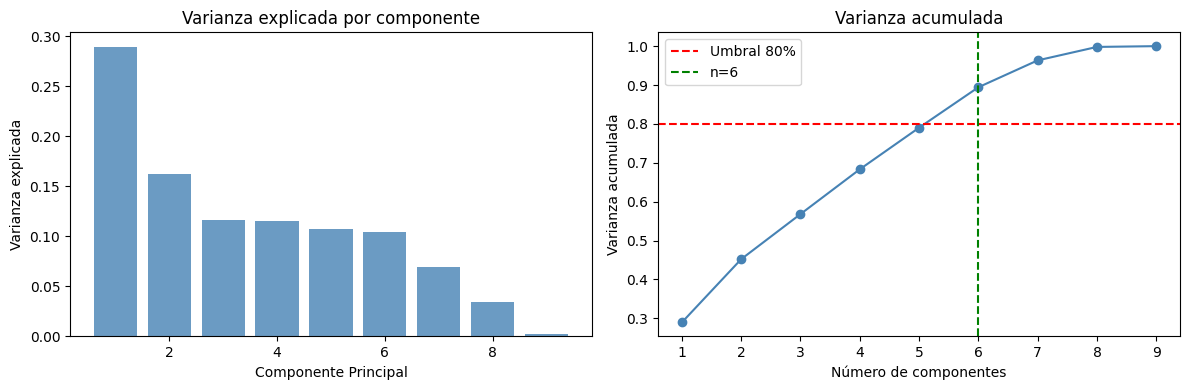


Shape tras PCA: (50000, 6)


In [4]:
# Determinar número óptimo de componentes (varianza acumulada ≥ 80%)
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.argmax(var_acum >= 0.80) + 1)
print(f"Componentes para explicar ≥80% de varianza: {n_components}")

# Aplicar PCA con n_components óptimo
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, alpha=0.8, color='steelblue')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza explicada')

axes[1].plot(range(1, len(var_acum) + 1), var_acum, marker='o', color='steelblue')
axes[1].axhline(0.80, color='red', linestyle='--', label='Umbral 80%')
axes[1].axvline(n_components, color='green', linestyle='--', label=f'n={n_components}')
axes[1].set_title('Varianza acumulada')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()

plt.tight_layout()
plt.savefig('../Visualizaciones/Gráficos/05_PCA_varianza_acumulada.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nShape tras PCA: {X_pca.shape}")

## 3. Clustering — K-Means

Se usa el **método del codo** para seleccionar `k`: se grafica la inercia (suma de distancias cuadradas al centroide) para distintos valores de `k`. El punto donde la curva "quiebra" indica el `k` óptimo.

**Justificación de K-Means**: algoritmo eficiente y escalable para grandes volúmenes, adecuado cuando se trabaja con features normalizadas. Se inicializa con `k-means++` para mayor estabilidad.

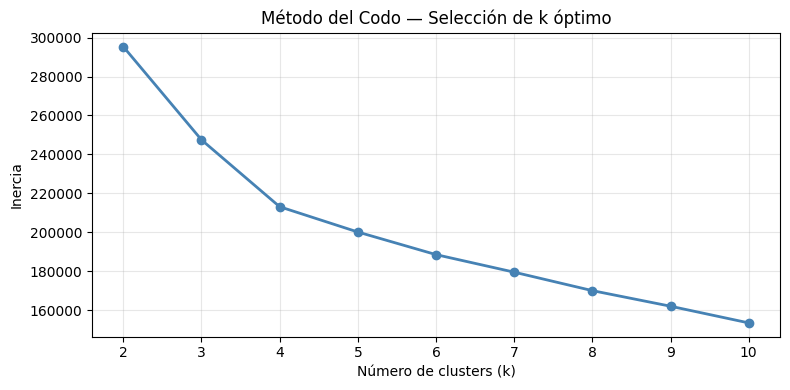

In [5]:
# Método del codo — inercia para k en [2, 10]
inercias = []
rango_k = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_pca)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo — Selección de k óptimo')
plt.xticks(rango_k)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../Visualizaciones/Gráficos/06_KMeans_codo.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Ajustar K-Means con k óptimo
# Ajustar K_OPTIMO según el quiebre observado en el gráfico del codo
K_OPTIMO = 4  # valor sugerido; modificar según el gráfico

km_final = KMeans(n_clusters=K_OPTIMO, init='k-means++', random_state=42, n_init=10)
etiquetas = km_final.fit_predict(X_pca)
X_sample['cluster'] = etiquetas

print(f"K seleccionado: {K_OPTIMO}")
print(f"\nDistribución de clusters:")
print(pd.Series(etiquetas).value_counts().sort_index())

K seleccionado: 4

Distribución de clusters:
0    12687
1    13371
2    10247
3    13695
Name: count, dtype: int64


## 4. Evaluación y Perfilado de Clusters

**Silhouette Score**: mide qué tan bien separados están los clusters. Rango [-1, 1]:
- > 0.5 → buena separación
- 0.2–0.5 → estructura moderada
- < 0.2 → clusters solapados

Silhouette Score (k=4): 0.2539


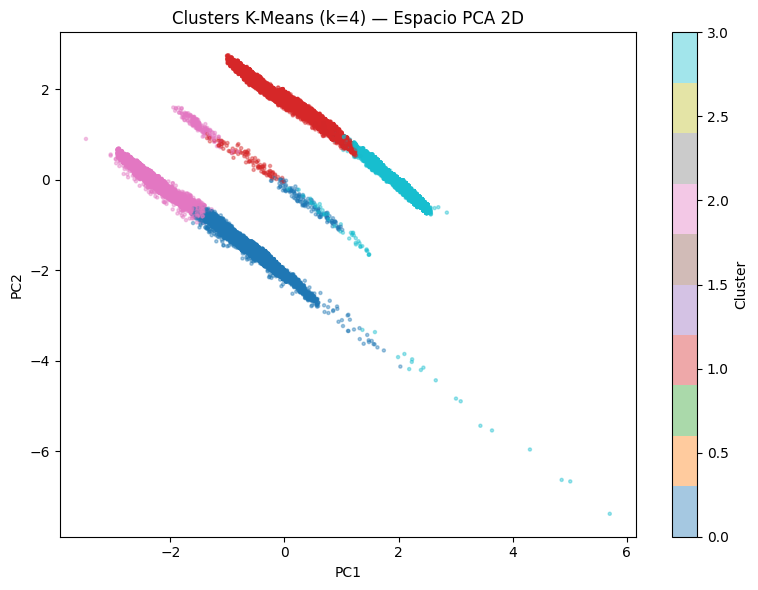

In [7]:
# Silhouette Score (muestra de 10k para velocidad)
sil = silhouette_score(X_pca, etiquetas, sample_size=10000, random_state=42)
print(f"Silhouette Score (k={K_OPTIMO}): {sil:.4f}")

# Visualización de clusters en 2D (primeros 2 componentes de PCA)
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=etiquetas, cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Clusters K-Means (k={K_OPTIMO}) — Espacio PCA 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('../Visualizaciones/Gráficos/07_clusters_scatter_2D.png', dpi=150, bbox_inches='tight')
plt.show()

,INTENTOS,Hora,MIN
cluster,,,
0,3.62,13.58,31.77
1,2.17,13.17,31.40
2,1.71,12.16,31.07
3,5.17,13.37,30.67


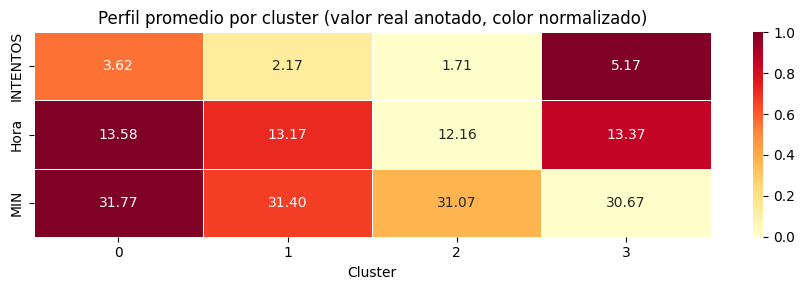

In [8]:
# Perfil promedio por cluster (features numéricas originales)
perfil = X_sample.groupby('cluster')[features_num].mean().round(2)
display(perfil)

# Heatmap de perfiles (normalizado para comparar escalas)
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(perfil_norm.T, annot=perfil.T, fmt='.2f',
            cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Perfil promedio por cluster (valor real anotado, color normalizado)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig('../Visualizaciones/Gráficos/08_clusters_perfil_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

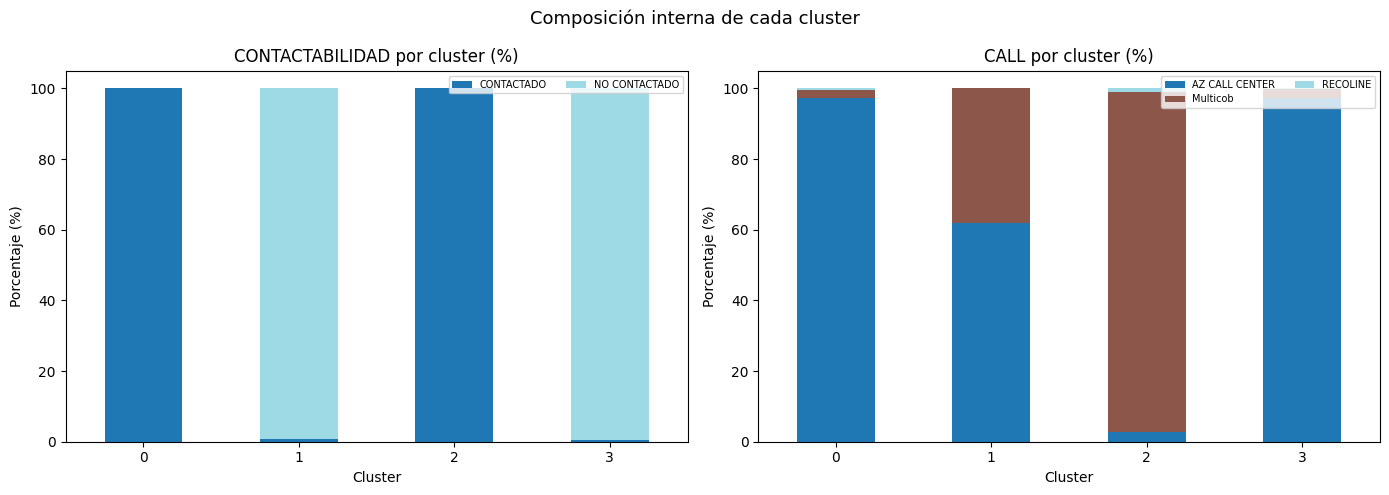

In [9]:
# Distribución de CONTACTABILIDAD y CALL por cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col_cat in zip(axes, ['CONTACTABILIDAD', 'CALL']):
    col_original = df[col_cat].fillna('DESCONOCIDO').iloc[idx].reset_index(drop=True)
    temp = pd.DataFrame({'cluster': etiquetas, col_cat: col_original})
    tabla = pd.crosstab(temp['cluster'], temp[col_cat], normalize='index') * 100
    tabla.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', legend=True)
    ax.set_title(f'{col_cat} por cluster (%)')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Porcentaje (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(loc='upper right', fontsize=7, ncol=2)

plt.suptitle('Composición interna de cada cluster', fontsize=13)
plt.tight_layout()
plt.savefig('../Visualizaciones/Gráficos/09_clusters_contactabilidad_call.png', dpi=150, bbox_inches='tight')
plt.show()